In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

np.random.seed(42)

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (8, 5),
    "axes.grid": True
})

In [ ]:
def create_network(n_agents, topology="erdos", p=0.3):
    if topology == "erdos":
        G = nx.erdos_renyi_graph(n_agents, p, seed=42)
        while not nx.is_connected(G):
            G = nx.erdos_renyi_graph(n_agents, p)
    elif topology == "ring":
        G = nx.cycle_graph(n_agents)
    elif topology == "complete":
        G = nx.complete_graph(n_agents)
    else:
        raise ValueError("Unknown topology")


    A = nx.to_numpy_array(G)
    D = np.diag(A.sum(axis=1))
    L = D - A

    return G, L


def random_initial_state(n_agents, low=0, high=10):
    return np.random.uniform(low, high, n_agents)

In [ ]:
def run_continuous_consensus(L, x0, t_span=(0, 50), n_points=1000):
    n = len(x0)
    t_eval = np.linspace(t_span[0], t_span[1], n_points)

    def dynamics(t, x):
        return -L @ x

    sol = solve_ivp(dynamics, t_span, x0, t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

    states = sol.y.T
    t = sol.t
    error = np.max(states, axis=1) - np.min(states, axis=1)

    consensus_val = np.mean(x0)
    return {
        "t": t,
        "states": states,
        "error": error,
        "consensus_val": consensus_val,
        "comm_events": None,
        "is_continuous": True
    }

In [ ]:
def run_event_triggered_consensus(L, A, x0, sigma=0.1, t_span=(0, 50), dt=0.001):
    n = len(x0)
    t_arr = np.arange(t_span[0], t_span[1] + dt, dt)
    n_steps = len(t_arr)

    x = x0.copy().astype(float)
    x_hat = x0.copy().astype(float)

    states_history = np.zeros((n_steps, n))
    states_history[0] = x

    trigger_counts = np.zeros(n, dtype=int)
    trigger_times = [[] for _ in range(n)]

    for step in range(1, n_steps):
        t = t_arr[step]
        for i in range(n):
            norm_e = abs(e[i])
            norm_x = abs(x[i])
            if norm_e >= sigma * norm_x + 1e-10:
                x_hat[i] = x[i]
                trigger_counts[i] += 1
                trigger_times[i].append(t)

        x_dot = -L @ x_hat
        x = x + dt * x_dot

        states_history[step] = x

    error = np.max(states_history, axis=1) - np.min(states_history, axis=1)
    total_comm = int(trigger_counts.sum())

    zeno_detected = False
    window = 0.1
    zeno_threshold = 50
    for times in trigger_times:
        times_arr = np.array(times)
        for i in range(len(times_arr)):
            in_window = np.sum((times_arr >= times_arr[i]) & (times_arr < times_arr[i] + window))
            if in_window > zeno_threshold:
                zeno_detected = True
                break
        if zeno_detected:
            break

    return {
        "t": t_arr,
        "states": states_history,
        "error": error,
        "trigger_counts": trigger_counts,
        "trigger_times": trigger_times,
        "total_comm": total_comm,
        "zeno_detected": zeno_detected,
        "is_continuous": False
    }

In [ ]:
def run_decaying_event_triggered(L, A, x0, epsilon0=1.0, alpha=0.05, t_span=(0, 50), dt=0.001):
    n = len(x0)
    t_arr = np.arange(t_span[0], t_span[1] + dt, dt)
    n_steps = len(t_arr)

    x = x0.copy().astype(float)
    x_hat = x0.copy().astype(float)

    states_history = np.zeros((n_steps, n))
    states_history[0] = x
    trigger_counts = np.zeros(n, dtype=int)

    for step in range(1, n_steps):
        t = t_arr[step]
        eps_t = epsilon0 * np.exp(-alpha * t)

        e = x - x_hat
        for i in range(n):
            if abs(e[i]) >= eps_t:
                x_hat[i] = x[i]
                trigger_counts[i] += 1

        x_dot = -L @ x_hat
        x = x + dt * x_dot
        states_history[step] = x

    error = np.max(states_history, axis=1) - np.min(states_history, axis=1)
    return {
        "t": t_arr,
        "states": states_history,
        "error": error,
        "trigger_counts": trigger_counts,
        "total_comm": int(trigger_counts.sum()),
        "zeno_detected": False,
        "is_continuous": False
    }


def run_neighbor_relative_triggered(L, A, x0, threshold=0.5, t_span=(0, 50), dt=0.001):
    n = len(x0)
    t_arr = np.arange(t_span[0], t_span[1] + dt, dt)
    n_steps = len(t_arr)

    x = x0.copy().astype(float)
    x_hat = x0.copy().astype(float)

    states_history = np.zeros((n_steps, n))
    states_history[0] = x
    trigger_counts = np.zeros(n, dtype=int)

    for step in range(1, n_steps):
        e = x - x_hat
        for i in range(n):
            neighbors_j = np.where(A[i] > 0)[0]
            diff = sum(abs(x[i] - x_hat[j]) for j in neighbors_j)
            if diff >= threshold:
                x_hat[i] = x[i]
                trigger_counts[i] += 1

        x_dot = -L @ x_hat
        x = x + dt * x_dot
        states_history[step] = x

    error = np.max(states_history, axis=1) - np.min(states_history, axis=1)
    return {
        "t": t_arr,
        "states": states_history,
        "error": error,
        "trigger_counts": trigger_counts,
        "total_comm": int(trigger_counts.sum()),
        "zeno_detected": False,
        "is_continuous": False
    }

In [ ]:
def convergence_time(error, t_arr, threshold=1e-2):
    for idx, e in enumerate(error):
        if e < threshold:
            return t_arr[idx]
    return t_arr[-1]

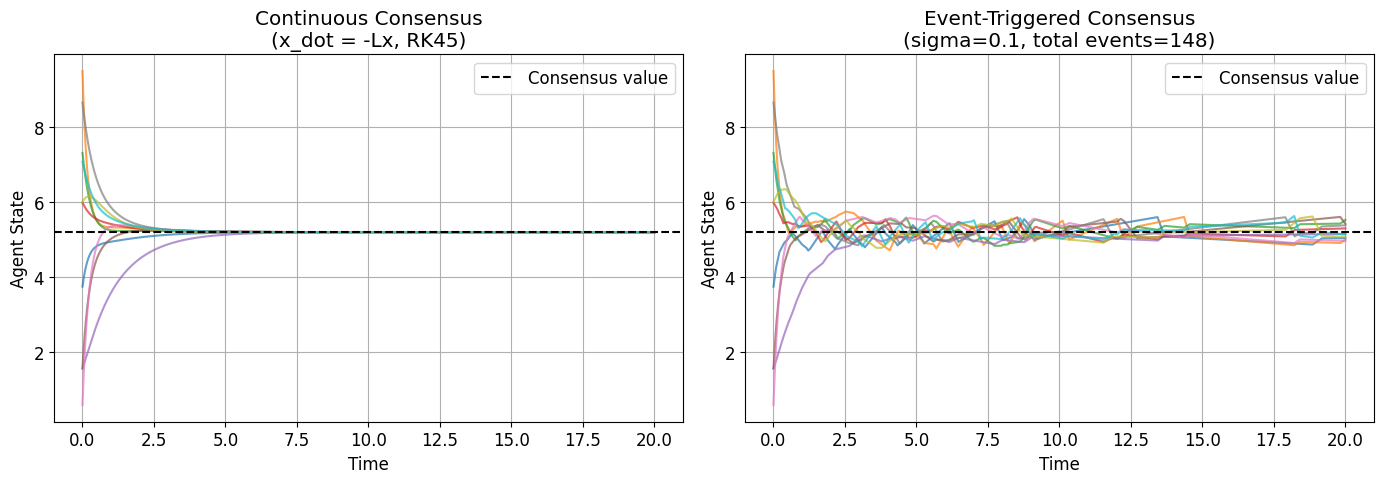

Consensus value (mean of x0): 5.2014
Continuous final mean: 5.2014
Event-triggered final mean: 5.2014


In [ ]:
n_agents = 10
G, L = create_network(n_agents, topology="erdos")
A = nx.to_numpy_array(G)
x0 = random_initial_state(n_agents)

T = 20

res_cont = run_continuous_consensus(L, x0, t_span=(0, T), n_points=2000)

res_et = run_event_triggered_consensus(L, A, x0, sigma=0.1, t_span=(0, T), dt=0.005)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(n_agents):
    axes[0].plot(res_cont["t"], res_cont["states"][:, i], alpha=0.7)
axes[0].set_title("Continuous Consensus\n(x_dot = -Lx, RK45)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Agent State")
axes[0].axhline(np.mean(x0), ls='--', color='k', label='Consensus value')
axes[0].legend()

for i in range(n_agents):
    axes[1].plot(res_et["t"], res_et["states"][:, i], alpha=0.7)
axes[1].set_title(f"Event-Triggered Consensus\n(sigma=0.1, total events={res_et['total_comm']})")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Agent State")
axes[1].axhline(np.mean(x0), ls='--', color='k', label='Consensus value')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Consensus value (mean of x0): {np.mean(x0):.4f}")
print(f"Continuous final mean: {res_cont['states'][-1].mean():.4f}")
print(f"Event-triggered final mean: {res_et['states'][-1].mean():.4f}")

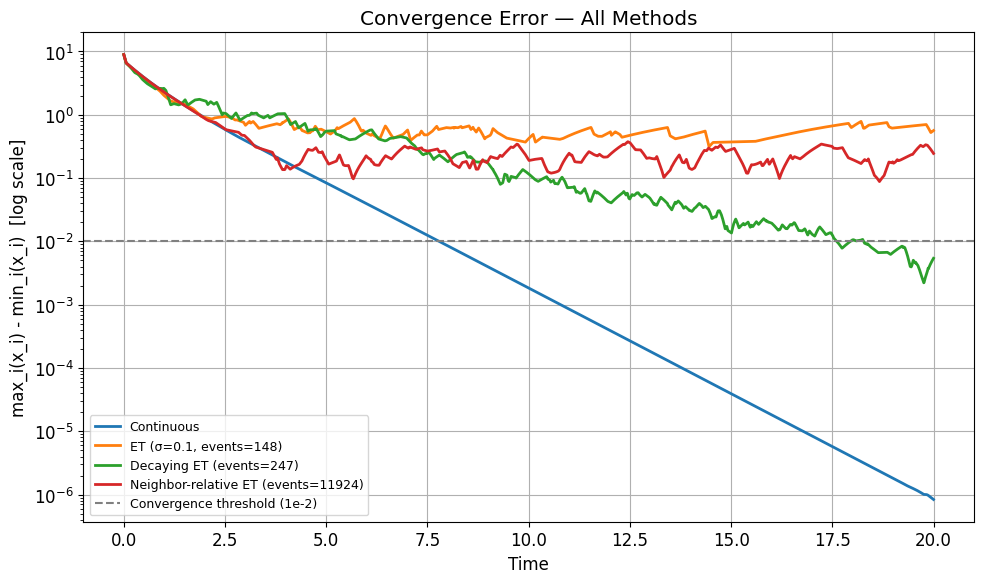

Method                      Conv. Time   Total Events     Zeno
-----------------------------------------------------------------
Continuous                       7.794 N/A (continuous)      N/A
ET (σ=0.1)                      20.000            148    False
Decaying ET                     17.615            247    False
Neighbor-relative ET            20.000          11924    False


In [ ]:
res_decaying = run_decaying_event_triggered(L, A, x0, epsilon0=2.0, alpha=0.3, t_span=(0, T), dt=0.005)
res_neighbor = run_neighbor_relative_triggered(L, A, x0, threshold=0.3, t_span=(0, T), dt=0.005)

plt.figure(figsize=(10, 6))
plt.semilogy(res_cont["t"], res_cont["error"] + 1e-12, label="Continuous", lw=2)
plt.semilogy(res_et["t"],  res_et["error"] + 1e-12, label=f"ET (σ=0.1, events={res_et['total_comm']})", lw=2)
plt.semilogy(res_decaying["t"], res_decaying["error"] + 1e-12, label=f"Decaying ET (events={res_decaying['total_comm']})", lw=2)
plt.semilogy(res_neighbor["t"], res_neighbor["error"] + 1e-12, label=f"Neighbor-relative ET (events={res_neighbor['total_comm']})", lw=2)
plt.axhline(1e-2, ls='--', color='gray', label='Convergence threshold (1e-2)')
plt.xlabel("Time")
plt.ylabel("max_i(x_i) - min_i(x_i)  [log scale]")
plt.title("Convergence Error — All Methods")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

methods = {
    "Continuous": res_cont,
    "ET (σ=0.1)": res_et,
    "Decaying ET": res_decaying,
    "Neighbor-relative ET": res_neighbor,}

print(f"{'Method':<25} {'Conv. Time':>12} {'Total Events':>14} {'Zeno':>8}")
print("-" * 65)
for name, res in methods.items():
    ct = convergence_time(res["error"], res["t"])
    ev = res.get("total_comm", "N/A (continuous)")
    zeno = res.get("zeno_detected", "N/A")
    print(f"{name:<25} {ct:>12.3f} {str(ev):>14} {str(zeno):>8}")

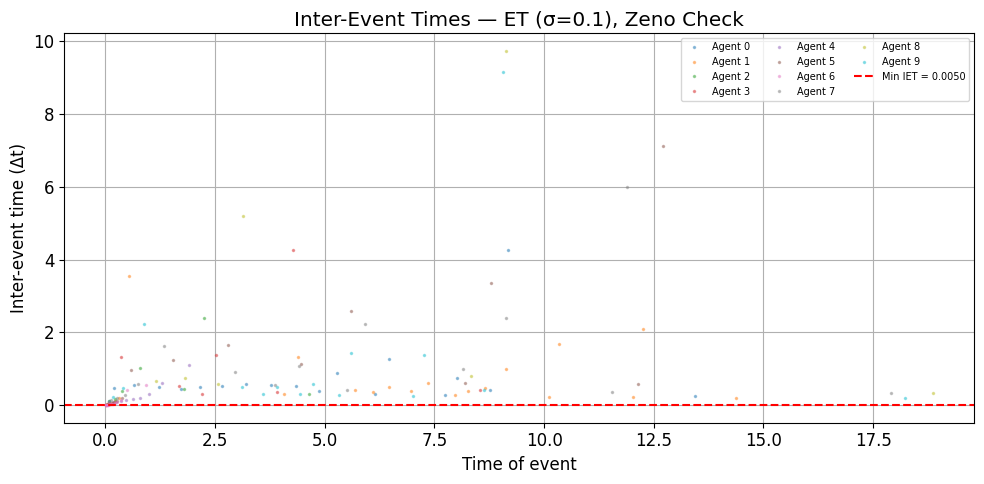

Minimum inter-event time: 0.005000
Mean inter-event time:    0.870652
Zeno detected: False
=> Positive minimum IET confirms NO Zeno behavior.


In [ ]:
def plot_inter_event_times(result, title="Inter-Event Times"):
    all_iet = []
    fig, ax = plt.subplots(figsize=(10, 5))

    for i, times in enumerate(result["trigger_times"]):
        if len(times) > 1:
            iets = np.diff(times)
            all_iet.extend(iets)
            ax.plot(times[:-1], iets, '.', alpha=0.4, markersize=3, label=f"Agent {i}")

    ax.set_xlabel("Time of event")
    ax.set_ylabel("Inter-event time (Δt)")
    ax.set_title(title)
    if all_iet:
        ax.axhline(np.min(all_iet), ls='--', color='red', label=f"Min IET = {np.min(all_iet):.4f}")
    ax.legend(fontsize=7, ncol=3)
    plt.tight_layout()
    plt.show()

    if all_iet:
        print(f"Minimum inter-event time: {np.min(all_iet):.6f}")
        print(f"Mean inter-event time:    {np.mean(all_iet):.6f}")
        print(f"Zeno detected: {result['zeno_detected']}")
        print("=> Positive minimum IET confirms NO Zeno behavior." if np.min(all_iet) > 1e-6
              else "=> WARNING: very small IET, possible Zeno behavior!")


plot_inter_event_times(res_et, title="Inter-Event Times — ET (σ=0.1), Zeno Check")

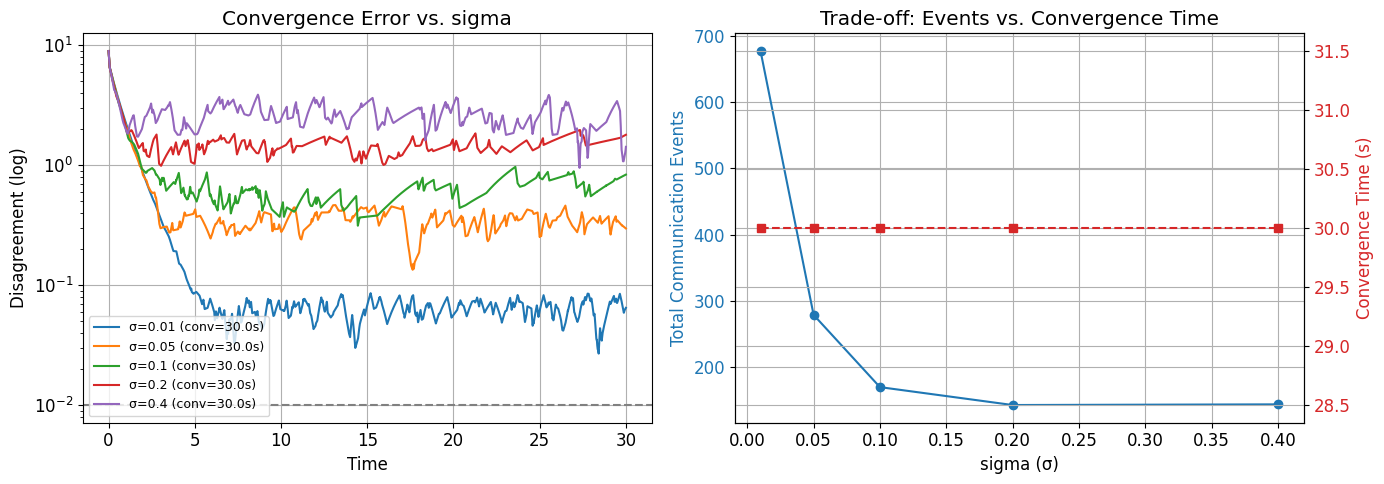

   sigma     Events   Conv. Time (s)
--------------------------------------
    0.01        677           30.000
    0.05        279           30.000
    0.10        170           30.000
    0.20        143           30.000
    0.40        144           30.000


In [ ]:
sigmas = [0.01, 0.05, 0.1, 0.2, 0.4]
T = 30

sigma_results = {}
for sigma in sigmas:
    r = run_event_triggered_consensus(L, A, x0, sigma=sigma, t_span=(0, T), dt=0.005)
    sigma_results[sigma] = r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sigma, r in sigma_results.items():
    ct = convergence_time(r["error"], r["t"])
    axes[0].semilogy(r["t"], r["error"] + 1e-12, label=f"σ={sigma} (conv={ct:.1f}s)")
axes[0].axhline(1e-2, ls='--', color='gray')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Disagreement (log)")
axes[0].set_title("Convergence Error vs. sigma")
axes[0].legend(fontsize=9)

total_events = [sigma_results[s]["total_comm"] for s in sigmas]
conv_times   = [convergence_time(sigma_results[s]["error"], sigma_results[s]["t"]) for s in sigmas]

ax2 = axes[1]
color1 = 'tab:blue'
color2 = 'tab:red'
ax2.set_xlabel("sigma (σ)")
ax2.set_ylabel("Total Communication Events", color=color1)
ax2.plot(sigmas, total_events, 'o-', color=color1)
ax2.tick_params(axis='y', labelcolor=color1)
ax2b = ax2.twinx()
ax2b.set_ylabel("Convergence Time (s)", color=color2)
ax2b.plot(sigmas, conv_times, 's--', color=color2)
ax2b.tick_params(axis='y', labelcolor=color2)
ax2.set_title("Trade-off: Events vs. Convergence Time")

plt.tight_layout()
plt.show()

print(f"{'sigma':>8} {'Events':>10} {'Conv. Time (s)':>16}")
print("-" * 38)
for sigma in sigmas:
    r = sigma_results[sigma]
    ct = convergence_time(r["error"], r["t"])
    print(f"{sigma:>8.2f} {r['total_comm']:>10} {ct:>16.3f}")

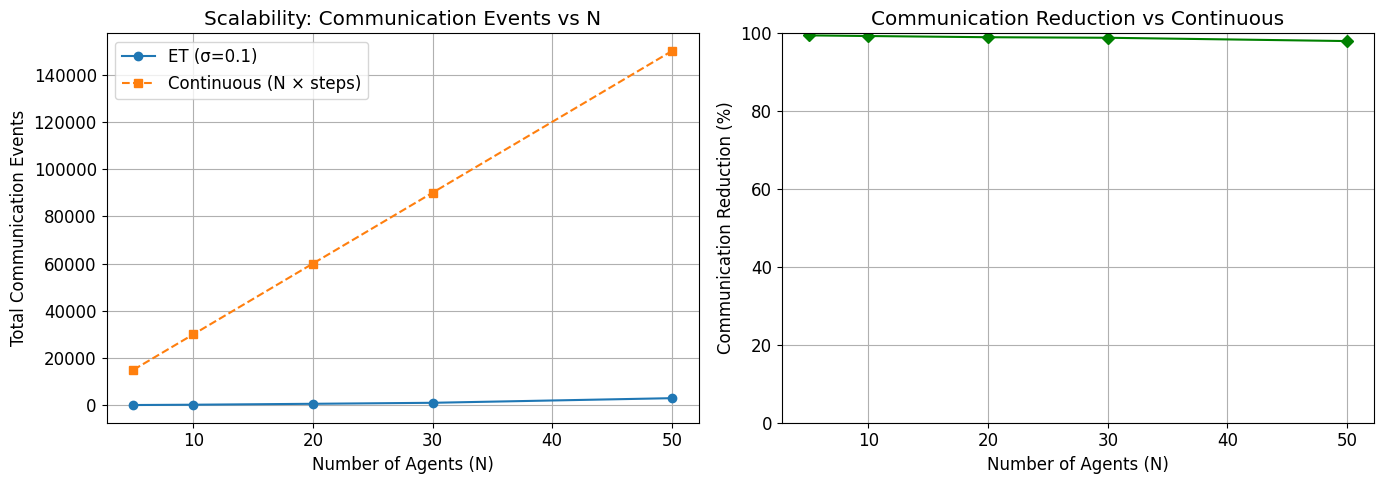

In [ ]:
agent_sizes = [5, 10, 20, 30, 50]
n_trials = 5
T_scale = 30
dt_scale = 0.01

scale_results = {"n": agent_sizes, "et_events": [], "cont_time": [], "et_time": []}

for n in agent_sizes:
    et_ev_list, et_ct_list = [], []
    for _ in range(n_trials):
        G_s, L_s = create_network(n, topology="erdos")
        A_s = nx.to_numpy_array(G_s)
        x0_s = np.random.uniform(0, 10, n)

        r = run_event_triggered_consensus(L_s, A_s, x0_s, sigma=0.1, t_span=(0, T_scale), dt=dt_scale)
        et_ev_list.append(r["total_comm"])
        et_ct_list.append(convergence_time(r["error"], r["t"]))

    scale_results["et_events"].append(np.mean(et_ev_list))
    scale_results["et_time"].append(np.mean(et_ct_list))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(agent_sizes, scale_results["et_events"], 'o-', label="ET (σ=0.1)")
cont_events = [n * (T_scale / dt_scale) for n in agent_sizes]
axes[0].plot(agent_sizes, cont_events, 's--', label="Continuous (N × steps)")
axes[0].set_xlabel("Number of Agents (N)")
axes[0].set_ylabel("Total Communication Events")
axes[0].set_title("Scalability: Communication Events vs N")
axes[0].legend()

reduction = [(c - e) / c * 100 for c, e in zip(cont_events, scale_results["et_events"])]
axes[1].plot(agent_sizes, reduction, 'D-', color='green')
axes[1].set_xlabel("Number of Agents (N)")
axes[1].set_ylabel("Communication Reduction (%)")
axes[1].set_title("Communication Reduction vs Continuous")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

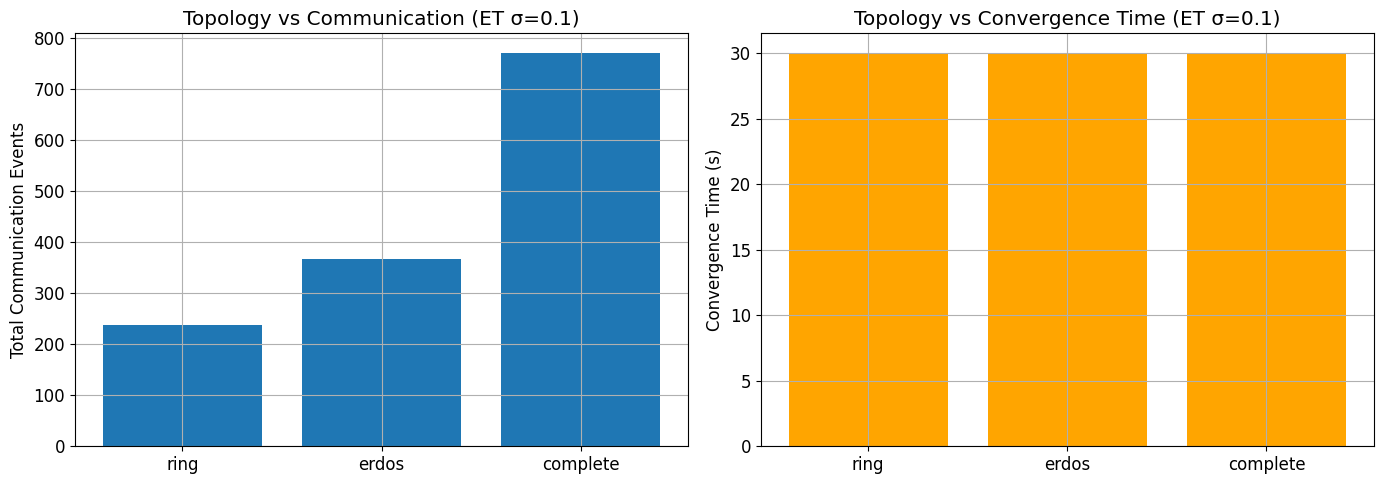

Topology         Events   Conv. Time (s)
------------------------------------------
ring              237.2           30.000
erdos             366.8           30.000
complete          770.8           30.000


In [ ]:
topologies = ["ring", "erdos", "complete"]
n_topo = 15
T_topo = 30
n_trials_topo = 5

topo_results = {}
for topo in topologies:
    ev_list, ct_list = [], []
    for _ in range(n_trials_topo):
        G_t, L_t = create_network(n_topo, topology=topo)
        A_t = nx.to_numpy_array(G_t)
        x0_t = np.random.uniform(0, 10, n_topo)

        r = run_event_triggered_consensus(L_t, A_t, x0_t, sigma=0.1, t_span=(0, T_topo), dt=0.01)
        ev_list.append(r["total_comm"])
        ct_list.append(convergence_time(r["error"], r["t"]))

    topo_results[topo] = {"events": np.mean(ev_list), "conv_time": np.mean(ct_list)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = list(topo_results.keys())
events = [topo_results[t]["events"] for t in names]
ctimes = [topo_results[t]["conv_time"] for t in names]

axes[0].bar(names, events)
axes[0].set_ylabel("Total Communication Events")
axes[0].set_title("Topology vs Communication (ET σ=0.1)")

axes[1].bar(names, ctimes, color='orange')
axes[1].set_ylabel("Convergence Time (s)")
axes[1].set_title("Topology vs Convergence Time (ET σ=0.1)")

plt.tight_layout()
plt.show()

print(f"{'Topology':<12} {'Events':>10} {'Conv. Time (s)':>16}")
print("-" * 42)
for t in names:
    print(f"{t:<12} {topo_results[t]['events']:>10.1f} {topo_results[t]['conv_time']:>16.3f}")

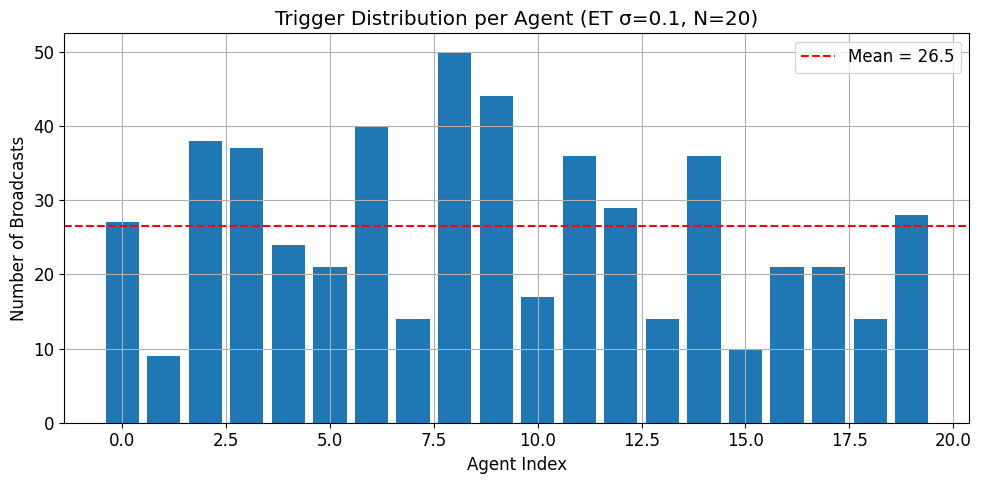

Min triggers per agent: 9
Max triggers per agent: 50
Mean triggers per agent: 26.50
Total: 530


In [ ]:
G_d, L_d = create_network(20, topology="erdos")
A_d = nx.to_numpy_array(G_d)
x0_d = random_initial_state(20)

res_d = run_event_triggered_consensus(L_d, A_d, x0_d, sigma=0.1, t_span=(0, 30), dt=0.005)

counts = res_d["trigger_counts"]

plt.figure(figsize=(10, 5))
plt.bar(range(len(counts)), counts)
plt.xlabel("Agent Index")
plt.ylabel("Number of Broadcasts")
plt.title("Trigger Distribution per Agent (ET σ=0.1, N=20)")
plt.axhline(counts.mean(), ls='--', color='red', label=f"Mean = {counts.mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Min triggers per agent: {counts.min()}")
print(f"Max triggers per agent: {counts.max()}")
print(f"Mean triggers per agent: {counts.mean():.2f}")
print(f"Total: {counts.sum()}")

In [ ]:
G_f, L_f = create_network(20, topology="erdos")
A_f = nx.to_numpy_array(G_f)
x0_f = random_initial_state(20)
T_f = 30

res_c  = run_continuous_consensus(L_f, x0_f, t_span=(0, T_f), n_points=3000)
res_e1 = run_event_triggered_consensus(L_f, A_f, x0_f, sigma=0.05, t_span=(0, T_f), dt=0.005)
res_e2 = run_event_triggered_consensus(L_f, A_f, x0_f, sigma=0.1, t_span=(0, T_f), dt=0.005)
res_e3 = run_event_triggered_consensus(L_f, A_f, x0_f, sigma=0.2, t_span=(0, T_f), dt=0.005)
res_dec = run_decaying_event_triggered(L_f, A_f, x0_f, epsilon0=2.0, alpha=0.3, t_span=(0, T_f), dt=0.005)
res_nbr = run_neighbor_relative_triggered(L_f, A_f, x0_f, threshold=0.3, t_span=(0, T_f), dt=0.005)

all_res = [
    ("Continuous (ODE)",        res_c,  "N/A"),
    ("ET exact σ=0.05 (PDF)",   res_e1, res_e1["total_comm"]),
    ("ET exact σ=0.1  (PDF)",   res_e2, res_e2["total_comm"]),
    ("ET exact σ=0.2  (PDF)",   res_e3, res_e3["total_comm"]),
    ("Decaying ET",              res_dec, res_dec["total_comm"]),
    ("Neighbor-relative ET",     res_nbr, res_nbr["total_comm"]),
]

print(f"{'Method':<30} {'Conv. Time (s)':>16} {'Events':>10} {'Zeno':>8}")
print("-" * 70)
for name, r, ev in all_res:
    ct = convergence_time(r["error"], r["t"])
    zeno = r.get("zeno_detected", "N/A")
    print(f"{name:<30} {ct:>16.3f} {str(ev):>10} {str(zeno):>8}")

cont_proxy = 20 * 3000
print("\nCommunication reduction vs continuous proxy:")
for name, r, ev in all_res[1:]:
    if isinstance(ev, int):
        pct = (cont_proxy - ev) / cont_proxy * 100
        print(f"  {name:<30}: {pct:.1f}% reduction")

Method                           Conv. Time (s)     Events     Zeno
----------------------------------------------------------------------
Continuous (ODE)                          2.061        N/A      N/A
ET exact σ=0.05 (PDF)                    30.000        801    False
ET exact σ=0.1  (PDF)                    30.000        731    False
ET exact σ=0.2  (PDF)                    30.000        619    False
Decaying ET                              17.385       1562    False
Neighbor-relative ET                     30.000      25438    False

Communication reduction vs continuous proxy:
  ET exact σ=0.05 (PDF)         : 98.7% reduction
  ET exact σ=0.1  (PDF)         : 98.8% reduction
  ET exact σ=0.2  (PDF)         : 99.0% reduction
  Decaying ET                   : 97.4% reduction
  Neighbor-relative ET          : 57.6% reduction
